In [868]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [869]:
df = pd.read_csv("Advertising.csv")

In [870]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [871]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [872]:
df.shape

(200, 5)

In [873]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [874]:
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [875]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [876]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [877]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [878]:
df.duplicated().sum()

np.int64(0)

In [879]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

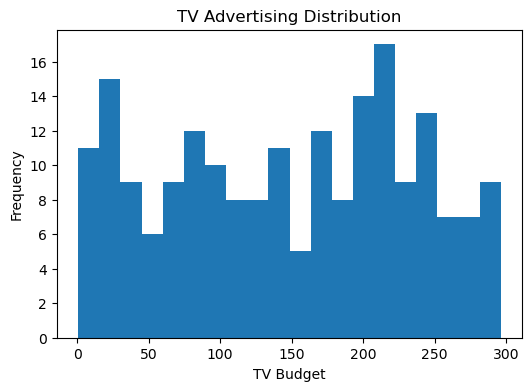

In [880]:
plt.figure(figsize=(6,4))
plt.hist(df["TV"], bins=20)
plt.title("TV Advertising Distribution")
plt.xlabel("TV Budget")
plt.ylabel("Frequency")
plt.show()

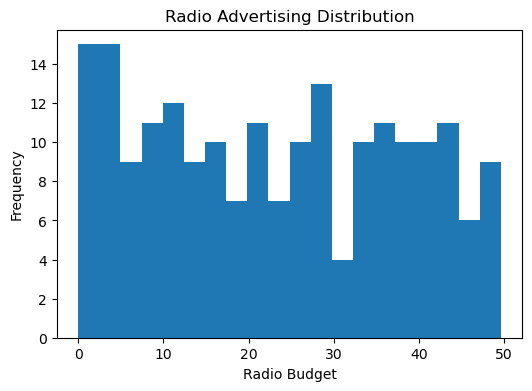

In [881]:
plt.figure(figsize=(6,4))
plt.hist(df["Radio"], bins=20)
plt.title("Radio Advertising Distribution")
plt.xlabel("Radio Budget")
plt.ylabel("Frequency")
plt.show()

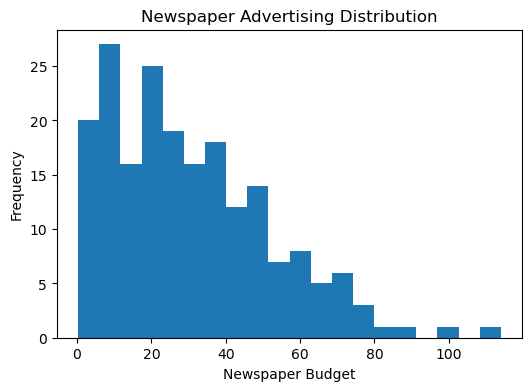

In [882]:
plt.figure(figsize=(6,4))
plt.hist(df["Newspaper"], bins=20)
plt.title("Newspaper Advertising Distribution")
plt.xlabel("Newspaper Budget")
plt.ylabel("Frequency")
plt.show()

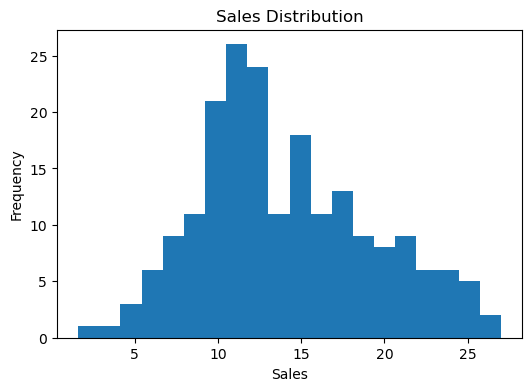

In [883]:
plt.figure(figsize=(6,4))
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

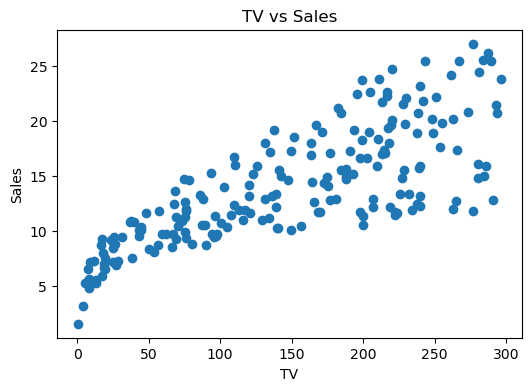

In [884]:
plt.figure(figsize=(6,4))
plt.scatter(df["TV"], df["Sales"])
plt.title("TV vs Sales")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

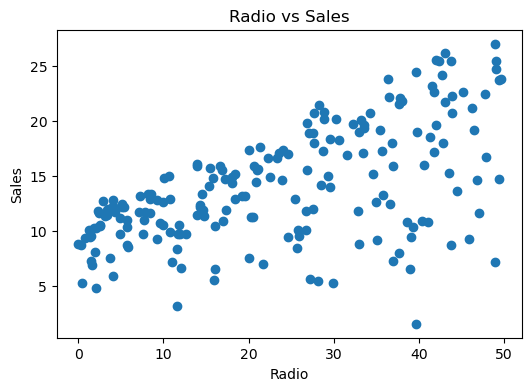

In [885]:
plt.figure(figsize=(6,4))
plt.scatter(df["Radio"], df["Sales"])
plt.title("Radio vs Sales")
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.show()

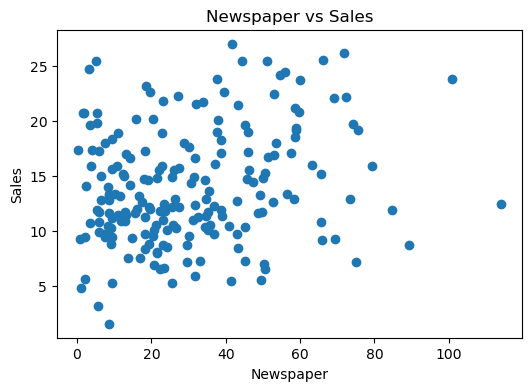

In [886]:
plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"], df["Sales"])
plt.title("Newspaper vs Sales")
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.show()

In [887]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


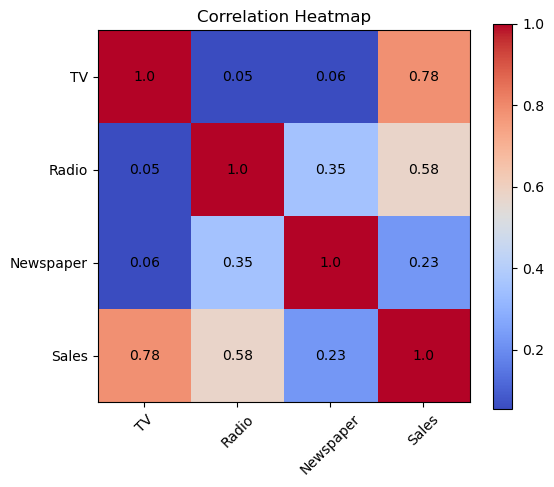

In [888]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha="center", va="center", color="black")

plt.title("Correlation Heatmap")
plt.show()

In [889]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

In [890]:
print(X.head())

print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [891]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [892]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)


In [893]:
model = LinearRegression()

In [894]:
model.fit(X_train, y_train)

LinearRegression()

In [895]:
y_pred = model.predict(X_test)

In [896]:
result = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

result.head(10)

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


In [897]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.4607567168117606


In [898]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3.1740973539761046


In [899]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.7815996615334502


In [900]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.899438024100912


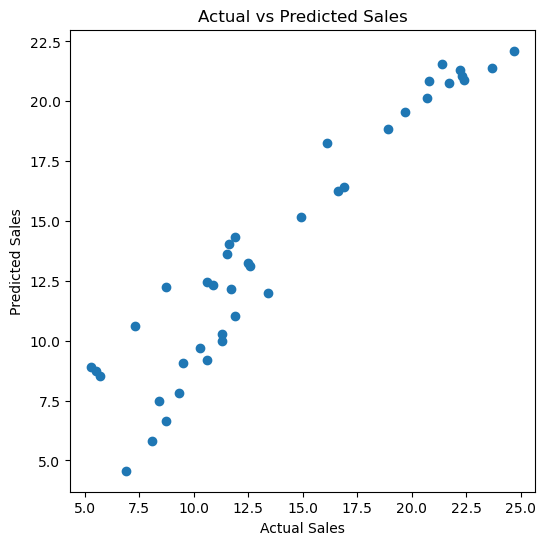

In [901]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [902]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [903]:
new_data = pd.DataFrame({
    "TV": [230],
    "Radio": [37],
    "Newspaper": [69]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 20.45759025215365


Conclusion

1. The Linear Regression model successfully predicts sales based on advertising expenditure.

2. TV advertising has the highest impact on sales.

3. Radio advertising also contributes positively.

4. Newspaper advertising has comparatively less impact.

5. The model achieved a good R² score, indicating reliable prediction performance.

6. Businesses can increase sales by optimizing advertising budgets, especially for TV and Radio campaigns.